In [1]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from umap import UMAP

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from functools import reduce


/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Features

In [2]:
orders = pd.read_parquet(ORDERS_PATH)
orders_products = pd.read_parquet(ORDER_PRODUCTS__PRIOR_PATH)
orders_orders_products = orders.merge(orders_products, how='inner',on = 'order_id')

The following features will be implemented: 

- Number of orders a user has made: _are they a shopper who orders a lot, or a shopper with fewer orders?_
- Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
- User frequency: _how often does the user shop?_
- Reorder frequency: Same product types?

Sebastian:
- Avg hour of day
- Avg dow

Possibly: 
- Frequency of department id -> which product types do they buy?



In [3]:


n_orders = (orders
              .groupby(["user_id"])
              .size()
              .reset_index(name="n_orders_u"))

products_pr_order = (orders_orders_products
 .groupby(["user_id", "order_id"])
 ["product_id"]
 .size()
 .reset_index(name='n_products_pr_order')
 .groupby(["user_id"])
 ["n_products_pr_order"]
 .mean()
 .reset_index(name='avg_products_pr_order')
 )

order_frequency = (orders
 .groupby(["user_id"])
 ["days_since_prior_order"]
 .mean()
 .reset_index(name='avg_days_since_prior_order')
 )

reorders = (orders_orders_products
 .groupby(["user_id"])
 .agg(n_products = ('reordered', 'size'),
      n_reorders = ('reordered', 'sum')
      )
 .reset_index()
 .assign(frac_reorders = lambda x: x["n_reorders"]/x['n_products'])
 )


X = reduce(lambda x,y: pd.merge(x,y, on='user_id'), [n_orders, products_pr_order, order_frequency, reorders])[["n_orders_u", "avg_products_pr_order", "avg_days_since_prior_order", "frac_reorders"]]
X

,n_orders_u,avg_products_pr_order,avg_days_since_prior_order,frac_reorders
0,11,5.900000,19.000000,0.694915
1,15,13.928571,16.285714,0.476923
2,13,7.333333,12.000000,0.625000
3,6,3.600000,17.000000,0.055556
4,5,9.250000,11.500000,0.378378
...,...,...,...,...
206204,4,10.666667,16.666667,0.250000
206205,68,4.253731,3.716418,0.473684
206206,17,13.937500,14.312500,0.587444
206207,50,13.816327,7.367347,0.707533


# Clustering and dimensionality reduction for plotting

In [13]:
dbscan = DBSCAN(eps=0.1)
y = dbscan.fit_predict(X)

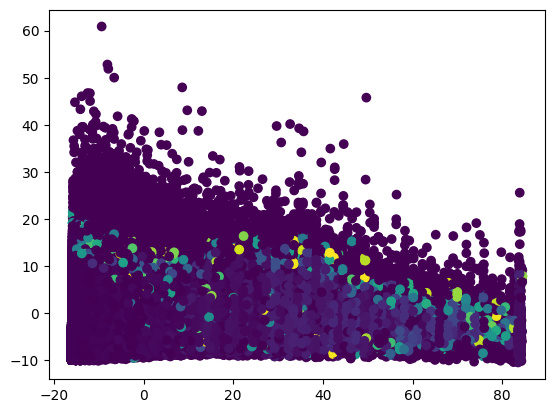

In [6]:
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X)

plt.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 206209 samples in 0.069s...
[t-SNE] Computed neighbors for 206209 samples in 2.196s...
[t-SNE] Computed conditional probabilities for sample 1000 / 206209
[t-SNE] Computed conditional probabilities for sample 2000 / 206209
[t-SNE] Computed conditional probabilities for sample 3000 / 206209
[t-SNE] Computed conditional probabilities for sample 4000 / 206209
[t-SNE] Computed conditional probabilities for sample 5000 / 206209
[t-SNE] Computed conditional probabilities for sample 6000 / 206209
[t-SNE] Computed conditional probabilities for sample 7000 / 206209
[t-SNE] Computed conditional probabilities for sample 8000 / 206209
[t-SNE] Computed conditional probabilities for sample 9000 / 206209
[t-SNE] Computed conditional probabilities for sample 10000 / 206209
[t-SNE] Computed conditional probabilities for sample 11000 / 206209
[t-SNE] Computed conditional probabilities for sample 12000 / 206209
[t-SNE] Computed conditional probabi

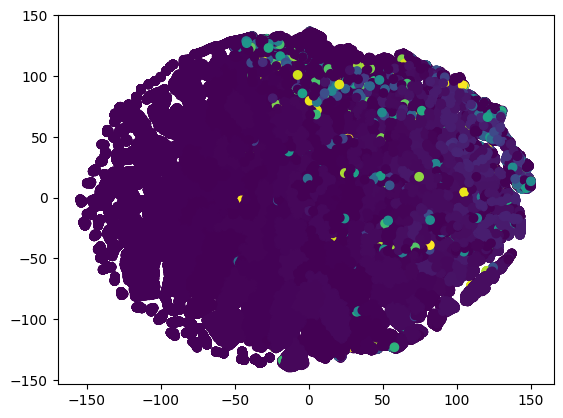

In [9]:
tsne = TSNE(n_components = 2, verbose=10, n_jobs=-1)
X_reduced_tsne = tsne.fit_transform(X)
dbscan = DBSCAN()
y_tsne = dbscan.fit_predict(X)

plt.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=y)

UMAP( verbose=True)
Fri Nov 21 23:26:24 2025 Construct fuzzy simplicial set
Fri Nov 21 23:26:24 2025 Finding Nearest Neighbors
Fri Nov 21 23:26:24 2025 Building RP forest with 28 trees
Fri Nov 21 23:26:25 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Fri Nov 21 23:26:28 2025 Finished Nearest Neighbor Search
Fri Nov 21 23:26:28 2025 Construct embedding


Epochs completed:   2%| ▏          4/200 [00:01]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         24/200 [00:02]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▏ 184/200 [00:11]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:12]

Fri Nov 21 23:33:16 2025 Finished embedding


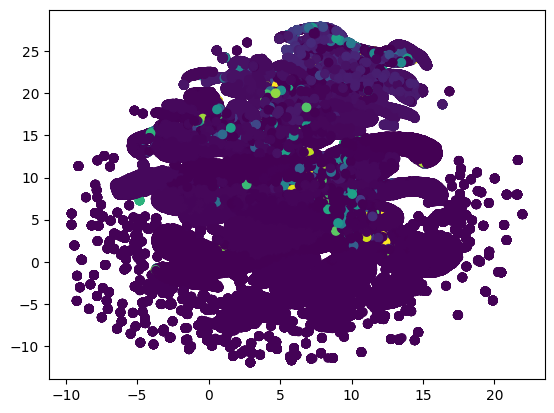

In [10]:

umap = UMAP(n_components=2, verbose=True, n_jobs=-1)
X_reduced_umap = umap.fit_transform(X)
dbscan = DBSCAN()

plt.scatter(X_reduced_umap[:,0], X_reduced_umap[:,1], c=y)